# UTS

## 1. Lakukan analisa klasifikasikan berita dengan extraksi fitur model topik modelling dengan classifier naïve bayes dan SVM

In [ ]:
!pip install plotly

In [ ]:
!pip install -q nltk contractions emoji pyspellchecker Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.1 MB/s eta 0:00:00


In [ ]:
!pip install gensim


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 10.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-1.16.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatibl

In [ ]:
import re
import sys
import time
import string
import warnings
from collections import Counter
import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from spellchecker import SpellChecker
import contractions
import emoji
from gensim.models import Word2Vec, FastText
from gensim import corpora, models
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from tqdm import tqdm
warnings.filterwarnings('ignore')

In [ ]:
nltk.download("punkt")
nltk.download("punkt_tab")

# Download stopwords
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Load Data Berita

In [ ]:
berita = pd.read_csv("Berita.csv")
berita

,No,judul,berita,tanggal,kategori,link
0,1,Airlangga Harap Kenaikan UMP Tingkatkan Daya B...,Menteri Koordinator (Menko) Bidang Perekonomia...,"Minggu, 01 Des 2024 23:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...
1,2,PT SIER Beri Penghargaan untuk 50 Tenant Terba...,"Dalam rangka memeriahkan hari jadi ke-50, PT S...","Minggu, 01 Des 2024 20:45 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...
2,3,Prabowo Bakal Bentuk Kementerian Penerimaan Ne...,Wacana Presiden Prabowo Subianto akan membentu...,"Minggu, 01 Des 2024 19:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
3,4,Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,"Minggu, 01 Des 2024 19:03 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
4,5,Pemerintah Segera Bentuk Satgas PHK Usai Tetap...,Pemerintah akan segera membentuk Satuan Tugas ...,"Minggu, 01 Des 2024 19:00 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
...,...,...,...,...,...,...
1495,1496,Laporan Sebab Tabrakan Pesawat-Black Hawk Dita...,Anggota Dewan Keselamatan Transportasi Nasiona...,"Jumat, 31 Jan 2025 04:40 WIB",Internasional,https://www.cnnindonesia.com/internasional/202...
1496,1497,"Israel Bebaskan 110 Sandera Palestina, Diantar...",Israel telah membebaskan 110 tahanan Palestina...,"Jumat, 31 Jan 2025 03:01 WIB",Internasional,https://www.cnnindonesia.com/internasional/202...
1497,1498,Hamas Konfirmasi Kematian Komandan Al Qassam M...,Hamas mengonfirmasi kematian kepala militernya...,"Jumat, 31 Jan 2025 02:30 WIB",Internasional,https://www.cnnindonesia.com/internasional/202...
1498,1499,Black Box American Airlines Ditemukan Usai Tab...,Tim penyelam diduga menemukan satu dari dua bl...,"Jumat, 31 Jan 2025 01:00 WIB",Internasional,https://www.cnnindonesia.com/internasional/202...


## Preprocessing

### Text Cleaning

In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()  # huruf kecil
    text = emoji.demojize(text)  # ubah emoji jadi teks, misal 😀 -> :grinning_face:
    text = re.sub(r'\d+', '', text)  # hapus angka
    text = text.translate(str.maketrans('', '', string.punctuation))  # hapus tanda baca
    text = re.sub(r'\W', ' ', text)  # hapus karakter non-kata
    text = BeautifulSoup(text, "html.parser").get_text()  # hapus tag HTML
    text = re.sub(r'\s+', ' ', text).strip()  # normalisasi spasi
    return text

# Baca CSV
berita_df = pd.read_csv("Berita.csv", dtype=str).fillna("")

# Terapkan langsung ke kolom target
berita_df["berita_clean"] = berita_df["berita"].apply(clean_text)

# Cleaning kolom target
berita_df["berita_clean"] = berita_df["berita"].apply(clean_text)

In [ ]:
print("\nBerita")
berita_df[["berita", "berita_clean"]].head(10)


Berita


,berita,berita_clean
0,Menteri Koordinator (Menko) Bidang Perekonomia...,menteri koordinator menko bidang perekonomian ...
1,"Dalam rangka memeriahkan hari jadi ke-50, PT S...",dalam rangka memeriahkan hari jadi ke pt surab...
2,Wacana Presiden Prabowo Subianto akan membentu...,wacana presiden prabowo subianto akan membentu...
3,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,bpjs ketenagakerjaan dan kementerian agama kem...
4,Pemerintah akan segera membentuk Satuan Tugas ...,pemerintah akan segera membentuk satuan tugas ...
5,Menko Bidang Infrastruktur dan Pembangunan Kew...,menko bidang infrastruktur dan pembangunan kew...
6,Kepala Badan Gizi Nasional Dadan Hindayana men...,kepala badan gizi nasional dadan hindayana men...
7,Menteri Koordinator Bidang Pangan Zulkifli Has...,menteri koordinator bidang pangan zulkifli has...
8,Uji coba alias commissioning pembangkit listri...,uji coba alias commissioning pembangkit listri...
9,Anak crazy rich pengusaha sawit Kalimantan Sam...,anak crazy rich pengusaha sawit kalimantan sam...


## Tokenisasi

In [ ]:
# Tokenisasi untuk PTA
berita_df["berita_tokens"] = berita_df["berita_clean"].apply(word_tokenize)

In [ ]:
print("\nBerita (berita_tokens):")
berita_df[["berita_clean", "berita_tokens"]].head(10)


Berita (berita_tokens):


,berita_clean,berita_tokens
0,menteri koordinator menko bidang perekonomian ...,"[menteri, koordinator, menko, bidang, perekono..."
1,dalam rangka memeriahkan hari jadi ke pt surab...,"[dalam, rangka, memeriahkan, hari, jadi, ke, p..."
2,wacana presiden prabowo subianto akan membentu...,"[wacana, presiden, prabowo, subianto, akan, me..."
3,bpjs ketenagakerjaan dan kementerian agama kem...,"[bpjs, ketenagakerjaan, dan, kementerian, agam..."
4,pemerintah akan segera membentuk satuan tugas ...,"[pemerintah, akan, segera, membentuk, satuan, ..."
5,menko bidang infrastruktur dan pembangunan kew...,"[menko, bidang, infrastruktur, dan, pembanguna..."
6,kepala badan gizi nasional dadan hindayana men...,"[kepala, badan, gizi, nasional, dadan, hindaya..."
7,menteri koordinator bidang pangan zulkifli has...,"[menteri, koordinator, bidang, pangan, zulkifl..."
8,uji coba alias commissioning pembangkit listri...,"[uji, coba, alias, commissioning, pembangkit, ..."
9,anak crazy rich pengusaha sawit kalimantan sam...,"[anak, crazy, rich, pengusaha, sawit, kalimant..."


## Stopword Removal

In [ ]:
# Stopwords untuk bahasa Indonesia
stop_words_id = set(stopwords.words('indonesian'))

# Filter stopwords di PTA
berita_df["berita_filtered"] = berita_df["berita_tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words_id]
)

In [ ]:
print("\nBerita (berita_filtered):")
berita_df[["berita_tokens", "berita_filtered"]].head(10)


Berita (berita_filtered):


,berita_tokens,berita_filtered
0,"[menteri, koordinator, menko, bidang, perekono...","[menteri, koordinator, menko, bidang, perekono..."
1,"[dalam, rangka, memeriahkan, hari, jadi, ke, p...","[rangka, memeriahkan, pt, surabaya, industrial..."
2,"[wacana, presiden, prabowo, subianto, akan, me...","[wacana, presiden, prabowo, subianto, membentu..."
3,"[bpjs, ketenagakerjaan, dan, kementerian, agam...","[bpjs, ketenagakerjaan, kementerian, agama, ke..."
4,"[pemerintah, akan, segera, membentuk, satuan, ...","[pemerintah, membentuk, satuan, tugas, pemutus..."
5,"[menko, bidang, infrastruktur, dan, pembanguna...","[menko, bidang, infrastruktur, pembangunan, ke..."
6,"[kepala, badan, gizi, nasional, dadan, hindaya...","[kepala, badan, gizi, nasional, dadan, hindaya..."
7,"[menteri, koordinator, bidang, pangan, zulkifl...","[menteri, koordinator, bidang, pangan, zulkifl..."
8,"[uji, coba, alias, commissioning, pembangkit, ...","[uji, coba, alias, commissioning, pembangkit, ..."
9,"[anak, crazy, rich, pengusaha, sawit, kalimant...","[anak, crazy, rich, pengusaha, sawit, kalimant..."


In [ ]:
print(berita_df.columns)


Index(['No', 'judul', 'berita', 'tanggal', 'kategori', 'link', 'berita_clean',
       'berita_tokens', 'berita_filtered'],
      dtype='object')


In [ ]:
cols_to_save = [
    "No",
    "judul",
    "berita",
    "tanggal",
    "kategori",
    "link",
    "berita_clean",
    "berita_tokens",
    "berita_filtered"
]

# Simpan ke CSV
berita_df[cols_to_save].to_csv("berita_processed.csv", index=False, encoding="utf-8-sig")

print("File berhasil disimpan sebagai berita_processed.csv")

File berhasil disimpan sebagai berita_processed.csv


## Analisa klasifikasikan berita dengan extraksi fitur model topik modelling dengan classifier naïve bayes dan SVM

In [ ]:
berita_df['tokens_list'] = berita_df['berita_filtered']
berita_df['tokens_str'] = berita_df['tokens_list'].apply(lambda x: " ".join(x))

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(berita_df['tokens_str'])

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

lda_model = LatentDirichletAllocation(n_components=15, random_state=42)
X_topics = lda_model.fit_transform(X_bow)


In [ ]:
terms = vectorizer.get_feature_names_out()
num_top_words = 15

for idx, topic in enumerate(lda_model.components_):
    print(f"\nTopik {idx+1}:")
    print(", ".join([terms[i] for i in topic.argsort()[:-num_top_words - 1:-1]]))


Topik 1:
indonesia, ahsanhendra, pelatih, juara, pensiun, masters, putra, dunia, cnn, ahsan, ganda, wakil, hendra, malaysia, persen

Topik 2:
israel, gencatan, senjata, gaza, trump, hamas, palestina, as, sandera, kesepakatan, presiden, warga, menteri, amerika, fase

Topik 3:
persen, minyak, pajak, presiden, ppn, pemerintah, kenaikan, rp, harga, putusan, partai, prabowo, uu, mentah, as

Topik 4:
program, makan, bergizi, gratis, mbg, rp, juta, persen, prabowo, indonesia, gizi, nasional, pemerintah, cnn, presiden

Topik 5:
indonesia, menteri, pertamina, energi, prabowo, presiden, bbm, sistem, bahlil, pemerintah, filipina, stasiun, cnn, miftah, pajak

Topik 6:
laut, pagar, tangerang, pt, nelayan, kpk, kkp, misterius, perikanan, kelautan, kementerian, hgb, proyek, sertifikat, terkait

Topik 7:
indonesia, timnas, piala, pelatih, pemain, kluivert, hasto, pssi, shin, pdip, dunia, tae, tim, yong, sty

Topik 8:
kebakaran, orang, israel, los, suriah, angeles, pesawat, wilayah, warga, serangan, m

In [ ]:
df_topics = pd.DataFrame(X_topics, columns=[f"topik_{i+1}" for i in range(lda_model.n_components)])
df_final = pd.concat([berita_df, df_topics], axis=1)
df_final["topik_dominan"] = df_topics.idxmax(axis=1).apply(lambda x: int(x.split("_")[1]))
print("\n=== Contoh 10 Data dengan Topik Dominan ===")
print(df_final[["judul", "kategori", "topik_dominan"]].head(10))
print("\n=== Distribusi Dokumen per Topik ===")
print(df_final["topik_dominan"].value_counts())


=== Contoh 10 Data dengan Topik Dominan ===
                                               judul kategori  topik_dominan
0  Airlangga Harap Kenaikan UMP Tingkatkan Daya B...  Ekonomi              4
1  PT SIER Beri Penghargaan untuk 50 Tenant Terba...  Ekonomi              3
2  Prabowo Bakal Bentuk Kementerian Penerimaan Ne...  Ekonomi             10
3  Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...  Ekonomi              4
4  Pemerintah Segera Bentuk Satgas PHK Usai Tetap...  Ekonomi             14
5  AHY Buka-bukaan Nasib Kelanjutan Pembangunan I...  Ekonomi             14
6  Badan Gizi Soal Biaya Makan Gratis Rp10 Ribu: ...  Ekonomi              4
7  Zulhas Minta Tambahan Anggaran Rp510 M Demi Ca...  Ekonomi              9
8             PLN Akan Uji Coba PLTS IKN 22 Desember  Ekonomi              5
9  Profil Jhony Saputra, Anak Haji Isam yang Jadi...  Ekonomi             12

=== Distribusi Dokumen per Topik ===
topik_dominan
13    194
8     190
6     146
7     142
4     123
14    

## SVM

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

X = X_topics
y = berita_df["kategori"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("=== Hasil Naive Bayes ===")
print(classification_report(y_test, y_pred_nb))

=== Hasil Naive Bayes ===
               precision    recall  f1-score   support

      Ekonomi       0.75      0.64      0.69        73
Internasional       0.88      0.88      0.88        84
     Nasional       0.60      0.67      0.64        70
     Olahraga       0.92      0.95      0.93        73

     accuracy                           0.79       300
    macro avg       0.79      0.79      0.78       300
 weighted avg       0.79      0.79      0.79       300



## Naive Bayes

In [ ]:
from sklearn import svm
from sklearn.metrics import classification_report

clf = svm.SVC(kernel="linear", random_state=42)
clf.fit(X_train, y_train)
y_pred_svm = clf.predict(X_test)

print("=== Hasil SVM ===")
print(classification_report(y_test, y_pred_svm))

=== Hasil SVM ===
               precision    recall  f1-score   support

      Ekonomi       0.70      0.74      0.72        73
Internasional       0.84      0.85      0.84        84
     Nasional       0.62      0.57      0.59        70
     Olahraga       0.92      0.92      0.92        73

     accuracy                           0.77       300
    macro avg       0.77      0.77      0.77       300
 weighted avg       0.77      0.77      0.77       300



In [ ]:
from sklearn.model_selection import train_test_split

# Gunakan dataframe yang benar
X = X_topics
y = berita_df["kategori"]

# Split data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


               precision    recall  f1-score   support

      Ekonomi       0.71      0.75      0.73        73
Internasional       0.87      0.87      0.87        84
     Nasional       0.65      0.60      0.62        70
     Olahraga       0.92      0.93      0.93        73

     accuracy                           0.79       300
    macro avg       0.79      0.79      0.79       300
 weighted avg       0.79      0.79      0.79       300



In [ ]:
dominant_topics = []

for doc_topics in X_topics:
    # Get the index of the dominant topic for the current document
    dominant_topic_index = doc_topics.argmax()
    # Get the probability of the dominant topic
    dominant_topic_probability = doc_topics[dominant_topic_index]
    dominant_topics.append((dominant_topic_index + 1, round(dominant_topic_probability, 3)))

df_dominant = pd.DataFrame(dominant_topics, columns=["Topik Dominan", "Proporsi"])

# Concatenate with the original dataframe and the topic distribution dataframe
df_result = pd.concat([berita_df.reset_index(drop=True), df_dominant.reset_index(drop=True), df_topics.reset_index(drop=True)], axis=1)

display(df_result[["judul", "kategori", "Topik Dominan", "Proporsi", "berita_clean"]])

,judul,kategori,Topik Dominan,Proporsi,berita_clean
0,Airlangga Harap Kenaikan UMP Tingkatkan Daya B...,Ekonomi,4,0.870,menteri koordinator menko bidang perekonomian ...
1,PT SIER Beri Penghargaan untuk 50 Tenant Terba...,Ekonomi,3,0.801,dalam rangka memeriahkan hari jadi ke pt surab...
2,Prabowo Bakal Bentuk Kementerian Penerimaan Ne...,Ekonomi,10,0.466,wacana presiden prabowo subianto akan membentu...
3,Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...,Ekonomi,4,0.444,bpjs ketenagakerjaan dan kementerian agama kem...
4,Pemerintah Segera Bentuk Satgas PHK Usai Tetap...,Ekonomi,14,0.808,pemerintah akan segera membentuk satuan tugas ...
...,...,...,...,...,...
1495,Laporan Sebab Tabrakan Pesawat-Black Hawk Dita...,Internasional,2,0.644,anggota dewan keselamatan transportasi nasiona...
1496,"Israel Bebaskan 110 Sandera Palestina, Diantar...",Internasional,2,0.547,israel telah membebaskan tahanan palestina pad...
1497,Hamas Konfirmasi Kematian Komandan Al Qassam M...,Internasional,8,0.587,hamas mengonfirmasi kematian kepala militernya...
1498,Black Box American Airlines Ditemukan Usai Tab...,Internasional,2,0.592,tim penyelam diduga menemukan satu dari dua bl...


# 2. Lakukan analisa clutering dokumen pada data email

In [43]:
df = pd.read_csv('spam.csv', encoding='latin1')

In [44]:
print("Dataset shape:", df.shape)
df

Dataset shape: (5572, 5)


,id,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,1,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,2,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,3,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,4,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,5,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,5568,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,5569,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,5570,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,5571,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [45]:
print("\nDataset info:")
df.info()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          5572 non-null   int64 
 1   Text        5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: int64(1), object(4)
memory usage: 217.8+ KB


## Preprocessing

In [46]:
df['Text']

,Text
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."
...,...
5567,This is the 2nd time we have tried 2 contact u...
5568,Will Ì_ b going to esplanade fr home?
5569,"Pity, * was in mood for that. So...any other s..."
5570,The guy did some bitching but I acted like i'd...


## Menghapus Mising Value

In [47]:
df.dropna(subset=['Text'], inplace=True)

# Hapus data duplikat
df.drop_duplicates(inplace=True)

## Fungsi untuk membersihkan teks

In [48]:
def clean_text(text):
    # Pastikan input adalah string
    if not isinstance(text, str):
          return ""

      text = text.lower() # 1. Ubah ke huruf kecil

    # Ganti karakter non-breaking space (U+00A0) dengan spasi biasa
    text = text.replace(u'\xa0', u' ')

    # Hapus semua karakter yang BUKAN huruf, angka, atau spasi
    text = re.sub(r'[^\w\s]', '', text)

    # Hapus semua angka
    text = re.sub(r'\d+', '', text)

    # Ganti spasi ganda/lebih menjadi satu spasi & hapus spasi di awal/akhir
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Terapkan pembersihan ke kolom 'isi'
df['cleaned_isi'] = df['Text'].apply(clean_text)

# Tampilkan DataFrame
display(df[['Text', 'cleaned_isi']].head())

,Text,cleaned_isi
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


## Tokenisasi

In [49]:
!{sys.executable} -m pip install nltk

In [50]:
nltk.download('punkt')
nltk.download('punkt_tab')

# Fungsi untuk melakukan tokenisasi
def tokenize_text(text):
    return word_tokenize(text)

# Terapkan tokenisasi ke kolom 'cleaned_isi'
df['tokenized_isi'] = df['cleaned_isi'].apply(tokenize_text)

# Tampilkan DataFrame dengan kolom hasil tokenisasi
display(df[['cleaned_isi', 'tokenized_isi']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,cleaned_isi,tokenized_isi
0,go until jurong point crazy available only in ...,"[go, until, jurong, point, crazy, available, o..."
1,ok lar joking wif u oni,"[ok, lar, joking, wif, u, oni]"
2,free entry in a wkly comp to win fa cup final ...,"[free, entry, in, a, wkly, comp, to, win, fa, ..."
3,u dun say so early hor u c already then say,"[u, dun, say, so, early, hor, u, c, already, t..."
4,nah i dont think he goes to usf he lives aroun...,"[nah, i, dont, think, he, goes, to, usf, he, l..."


## Stopword Removal

In [51]:
nltk.download('stopwords')

# Dapatkan Stop Word bahasa Indonesia
list_stopwords = set(stopwords.words('english'))

# Fungsi untuk menghapus stop words
def remove_stopwords(tokens):
    return [word for word in tokens if word not in list_stopwords]

# Terapkan penghapusan Stop Word ke kolom 'tokenized_isi'
df['stopwords_removed_isi'] = df['tokenized_isi'].apply(remove_stopwords)

# Tampilkan DataFrame
display(df[['tokenized_isi', 'stopwords_removed_isi']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,tokenized_isi,stopwords_removed_isi
0,"[go, until, jurong, point, crazy, available, o...","[go, jurong, point, crazy, available, bugis, n..."
1,"[ok, lar, joking, wif, u, oni]","[ok, lar, joking, wif, u, oni]"
2,"[free, entry, in, a, wkly, comp, to, win, fa, ...","[free, entry, wkly, comp, win, fa, cup, final,..."
3,"[u, dun, say, so, early, hor, u, c, already, t...","[u, dun, say, early, hor, u, c, already, say]"
4,"[nah, i, dont, think, he, goes, to, usf, he, l...","[nah, dont, think, goes, usf, lives, around, t..."


In [52]:
# Gabungkan semua token setelah stopword removal menjadi satu daftar
all_words_after_stopwords = [word for tokens in df['stopwords_removed_isi'] for word in tokens]

# Hitung frekuensi setiap kata
word_frequencies = Counter(all_words_after_stopwords)

# Menampilkan kata-kata yang paling umum dan frekuensinya
print("Top Most Frequent Words (Without Stemming):")
for word, frequency in word_frequencies.most_common(20): # Menampilkan 20 kata teratas
    print(f"{word}: {frequency}")

Top Most Frequent Words (Without Stemming):
u: 1143
call: 578
im: 464
get: 390
ur: 384
go: 282
dont: 279
free: 278
ok: 277
ltgt: 276
å: 274
know: 257
got: 251
like: 242
ill: 237
good: 234
come: 226
day: 211
time: 208
love: 195


In [53]:
# Buat DataFrame baru dengan isi berita asli, hasil preprocessing, dan kategori
processed_df = df[['Text', 'stopwords_removed_isi']].copy()

# Ganti nama kolom 'stopwords_removed_isi' menjadi 'hasil_preprocessing'
processed_df.rename(columns={'stopwords_removed_isi': 'hasil_preprocessing'}, inplace=True)

# Konversi frekuensi kata ke DataFrame
frequency_df = pd.DataFrame.from_dict(word_frequencies, orient='index', columns=['frequency'])
frequency_df.index.name = 'word'
frequency_df.sort_values(by='frequency', ascending=False, inplace=True)

# Simpan ke dua file CSV terpisah
processed_df.to_csv('hasil_preprocessing_emailUTS.csv', index=False, encoding='utf-8')
frequency_df.to_csv('frekuensi_kata_emailUTS.csv', encoding='utf-8')

print("Hasil preprocessing disimpan di 'hasil_preprocessing_emailUTS.csv'")
print("Frekuensi kata disimpan di 'frekuensi_kata_emailUTS.csv'")

Hasil preprocessing disimpan di 'hasil_preprocessing_emailUTS.csv'
Frekuensi kata disimpan di 'frekuensi_kata_emailUTS.csv'


In [54]:
hasil_preprocessing = "hasil_preprocessing_emailUTS.csv"
df = pd.read_csv(hasil_preprocessing)

# Tampilkan data
df

,Text,hasil_preprocessing
0,"Go until jurong point, crazy.. Available only ...","['go', 'jurong', 'point', 'crazy', 'available'..."
1,Ok lar... Joking wif u oni...,"['ok', 'lar', 'joking', 'wif', 'u', 'oni']"
2,Free entry in 2 a wkly comp to win FA Cup fina...,"['free', 'entry', 'wkly', 'comp', 'win', 'fa',..."
3,U dun say so early hor... U c already then say...,"['u', 'dun', 'say', 'early', 'hor', 'u', 'c', ..."
4,"Nah I don't think he goes to usf, he lives aro...","['nah', 'dont', 'think', 'goes', 'usf', 'lives..."
...,...,...
5567,This is the 2nd time we have tried 2 contact u...,"['nd', 'time', 'tried', 'contact', 'u', 'u', '..."
5568,Will Ì_ b going to esplanade fr home?,"['ì_', 'b', 'going', 'esplanade', 'fr', 'home']"
5569,"Pity, * was in mood for that. So...any other s...","['pity', 'mood', 'soany', 'suggestions']"
5570,The guy did some bitching but I acted like i'd...,"['guy', 'bitching', 'acted', 'like', 'id', 'in..."


In [55]:
frekuensi_kata = "frekuensi_kata_emailUTS.csv"
df = pd.read_csv(frekuensi_kata)

# Tampilkan data
df

,word,frequency
0,u,1143
1,call,578
2,im,464
3,get,390
4,ur,384
...,...,...
8479,practising,1
8480,rupaul,1
8481,baskets,1
8482,dane,1


## Analisa clutering dokumen pada data email

In [56]:
# Memuat Dataset
try:
    df = pd.read_csv('hasil_preprocessing_emailUTS.csv')
    print(f"\nDataset berhasil dimuat. Jumlah data: {len(df)} baris.")
    print("Contoh data awal:")
    print(df.head())
except FileNotFoundError:
    print("\nError: File tidak ditemukan. Pastikan nama file CSV sudah benar.")
    # Jika file tidak ditemukan, hentikan proses.
    # df = pd.DataFrame()


Dataset berhasil dimuat. Jumlah data: 5572 baris.
Contoh data awal:
                                                Text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                 hasil_preprocessing  
0  ['go', 'jurong', 'point', 'crazy', 'available'...  
1         ['ok', 'lar', 'joking', 'wif', 'u', 'oni']  
2  ['free', 'entry', 'wkly', 'comp', 'win', 'fa',...  
3  ['u', 'dun', 'say', 'early', 'hor', 'u', 'c', ...  
4  ['nah', 'dont', 'think', 'goes', 'usf', 'lives...  


In [59]:
from ast import literal_eval

df['tokens'] = df['hasil_preprocessing'].apply(literal_eval)
print(f"Data bersih dimuat. Jumlah data: {len(df)} baris.")

Data bersih dimuat. Jumlah data: 5572 baris.



Kamus dibuat dan difilter. Jumlah kata unik: 602

--- Menjalankan HDP untuk estimasi jumlah topik... ---


✅ HDP mengestimasi ada sekitar: 20 topik.

--- Menjalankan pencarian koherensi dari 5 hingga 40 topik... ---
Selesai menghitung untuk 5 topik. Skor Koherensi: 0.3769
Selesai menghitung untuk 10 topik. Skor Koherensi: 0.3791
Selesai menghitung untuk 15 topik. Skor Koherensi: 0.3762
Selesai menghitung untuk 20 topik. Skor Koherensi: 0.3390
Selesai menghitung untuk 25 topik. Skor Koherensi: 0.3703
Selesai menghitung untuk 30 topik. Skor Koherensi: 0.3761
Selesai menghitung untuk 35 topik. Skor Koherensi: 0.3909

Total waktu pencarian koherensi: 2.92 menit


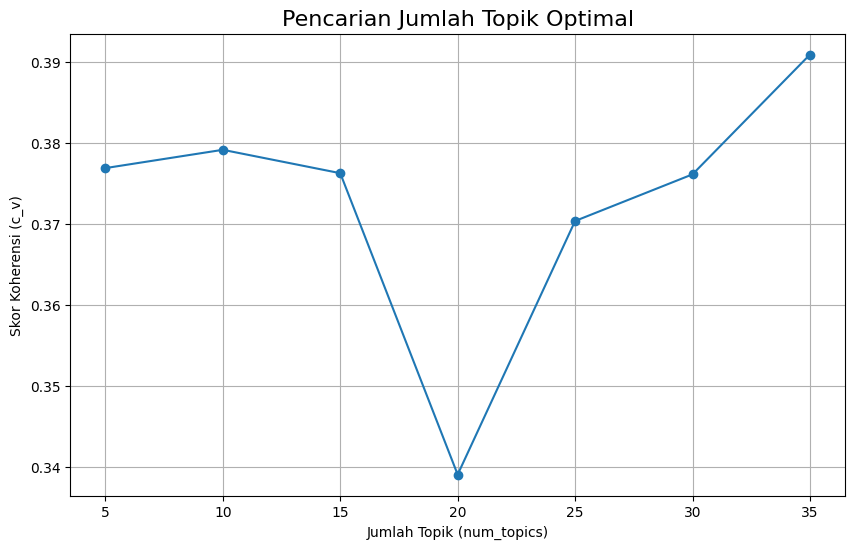


✅ Jumlah topik optimal yang ditemukan: 35

--- Melatih model LDA final dengan topik optimal... ---

--- Topik-topik yang Ditemukan oleh Model LDA ---
Topik: 25
Kata-kata: 0.102*"å" + 0.098*"call" + 0.067*"customer" + 0.059*"service" + 0.051*"claim" + 0.042*"receive" + 0.038*"prize" + 0.036*"speak" + 0.034*"live" + 0.033*"selected" + 0.033*"award" + 0.029*"please" + 0.027*"mobile" + 0.026*"cash" + 0.024*"guaranteed"

Topik: 9
Kata-kata: 0.165*"get" + 0.104*"please" + 0.067*"thanks" + 0.062*"message" + 0.057*"miss" + 0.057*"waiting" + 0.055*"call" + 0.040*"problem" + 0.033*"special" + 0.030*"leave" + 0.028*"pay" + 0.027*"tell" + 0.025*"dont" + 0.023*"till" + 0.021*"mail"

Topik: 33
Kata-kata: 0.184*"got" + 0.156*"still" + 0.132*"want" + 0.040*"go" + 0.038*"u" + 0.031*"thanx" + 0.030*"working" + 0.026*"watch" + 0.026*"wif" + 0.024*"though" + 0.019*"gd" + 0.019*"start" + 0.019*"eve" + 0.018*"work" + 0.018*"pretty"

Topik: 32
Kata-kata: 0.154*"good" + 0.092*"love" + 0.087*"well" + 0.079*"h

In [61]:
from gensim.corpora import Dictionary
from gensim.models import HdpModel, LdaMulticore
import time
import matplotlib.pyplot as plt
import numpy as np
from gensim.models.coherencemodel import CoherenceModel

# Siapkan data untuk Gensim
documents = df['tokens'].tolist()
dictionary = Dictionary(documents)
dictionary.filter_extremes(no_below=15, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in documents]
print(f"\nKamus dibuat dan difilter. Jumlah kata unik: {len(dictionary)}")


# Estimasi Jumlah Topik dengan HDP
print("\n--- Menjalankan HDP untuk estimasi jumlah topik... ---")
hdp_model = HdpModel(corpus=corpus, id2word=dictionary)
estimated_num_topics = len(hdp_model.print_topics())
print(f"✅ HDP mengestimasi ada sekitar: {estimated_num_topics} topik.")


# Mencari Jumlah Topik Terbaik dengan Plot Koherensi
def compute_coherence_values_multicore(dictionary, corpus, texts, limit, start=2, step=3):
    coherence_values = []
    start_time = time.time()
    for num_topics in range(start, limit, step):
        model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=num_topics,
                             random_state=42, passes=10, workers=3)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        current_coherence = coherencemodel.get_coherence()
        coherence_values.append(current_coherence)
        print(f"Selesai menghitung untuk {num_topics} topik. Skor Koherensi: {current_coherence:.4f}")
    total_time = time.time() - start_time
    print(f"\nTotal waktu pencarian koherensi: {total_time/60:.2f} menit")
    return coherence_values

# Atur rentang pencarian di sekitar hasil HDP
search_start = max(2, estimated_num_topics - 15)
search_limit = estimated_num_topics + 20
search_step = 5

print(f"\n--- Menjalankan pencarian koherensi dari {search_start} hingga {search_limit} topik... ---")
coherence_values = compute_coherence_values_multicore(dictionary=dictionary, corpus=corpus, texts=documents,
                                                    start=search_start, limit=search_limit, step=search_step)

# Tampilkan grafik
x = range(search_start, search_limit, search_step)
plt.figure(figsize=(10, 6))
plt.plot(x, coherence_values, marker='o')
plt.title("Pencarian Jumlah Topik Optimal", fontsize=16)
plt.xlabel("Jumlah Topik (num_topics)")
plt.ylabel("Skor Koherensi (c_v)")
plt.xticks(x)
plt.grid(True)
plt.show()

# Pilih jumlah topik terbaik (yang memiliki skor koherensi tertinggi)
optimal_num_topics = x[np.argmax(coherence_values)]
print(f"\n✅ Jumlah topik optimal yang ditemukan: {optimal_num_topics}")


# Latih Model LDA Final & Ekstrak Fitur ---
print("\n--- Melatih model LDA final dengan topik optimal... ---")
lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=optimal_num_topics,
                         random_state=42, passes=15)

print("\n--- Topik-topik yang Ditemukan oleh Model LDA ---")
    # Tampilkan 15 kata teratas untuk setiap topik
for idx, topic in lda_model.print_topics(num_words=15):
    print(f"Topik: {idx}")
    print(f"Kata-kata: {topic}\n")

# Ekstrak fitur (distribusi topik) untuk setiap dokumen
def get_lda_features(lda_model, bow_corpus):
    features = []
    for doc_bow in bow_corpus:
        topic_distribution = lda_model.get_document_topics(doc_bow, minimum_probability=0)
        doc_features = [0.0] * optimal_num_topics
        for topic_id, prob in topic_distribution:
            doc_features[topic_id] = prob
        features.append(doc_features)
    return np.array(features)

X = get_lda_features(lda_model, corpus)

print("Ekstraksi fitur LDA selesai.")
print(f"Bentuk matriks fitur (X): {X.shape}")


--- Mencari K Optimal dengan Silhouette Score (Metode Kuantitatif) ---
Untuk K = 2, Silhouette Score-nya adalah 0.0268
Untuk K = 3, Silhouette Score-nya adalah 0.0143
Untuk K = 4, Silhouette Score-nya adalah 0.0278
Untuk K = 5, Silhouette Score-nya adalah 0.0348
Untuk K = 6, Silhouette Score-nya adalah 0.0546
Untuk K = 7, Silhouette Score-nya adalah 0.0690
Untuk K = 8, Silhouette Score-nya adalah 0.0799
Untuk K = 9, Silhouette Score-nya adalah 0.0844
Untuk K = 10, Silhouette Score-nya adalah 0.0921
Untuk K = 11, Silhouette Score-nya adalah 0.1053
Untuk K = 12, Silhouette Score-nya adalah 0.1109
Untuk K = 13, Silhouette Score-nya adalah 0.1235
Untuk K = 14, Silhouette Score-nya adalah 0.1311
Untuk K = 15, Silhouette Score-nya adalah 0.1376


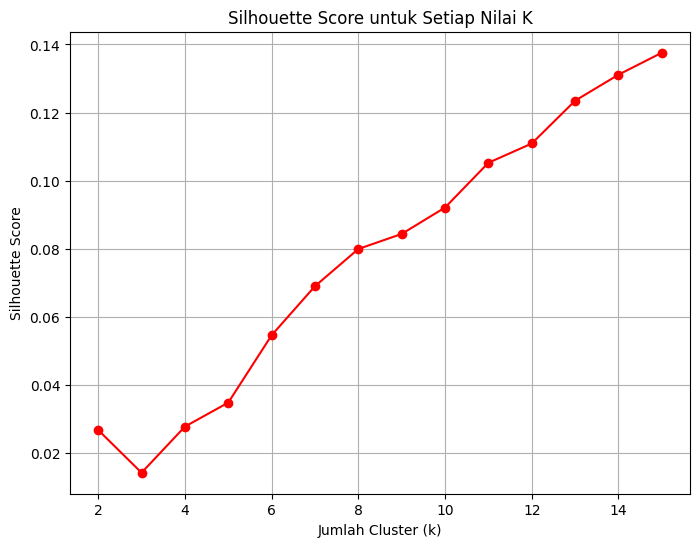


✅ Berdasarkan Silhouette Score, K terbaik adalah: 15

--- Menjalankan K-Means final dengan K=15... ---

Contoh email dari setiap cluster yang ditemukan:

----- CLUSTER 0 -----
- Even my brother is not like to speak with me. They treat me like aids patent....
- IÛ÷m going to try for 2 months ha ha only joking...

----- CLUSTER 1 -----
- I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today....
- Ffffffffff. Alright no way I can meet up with you sooner?...

----- CLUSTER 2 -----
- Oh k...i'm watching here:)...
- What you thinked about me. First time you saw me in class....

----- CLUSTER 3 -----
- WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only....
- No calls..messages..missed calls...

----- CLUSTER 4 -----
- As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Call

In [63]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Menemukan K Optimal dengan Silhouette Score
print("\n--- Mencari K Optimal dengan Silhouette Score (Metode Kuantitatif) ---")
K_range = range(2, 16)
silhouette_scores = []
for k in K_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(X)
    score = silhouette_score(X, kmeans_model.labels_)
    silhouette_scores.append(score)
    print(f"Untuk K = {k}, Silhouette Score-nya adalah {score:.4f}")

# Visualisasikan hasilnya
plt.figure(figsize=(8, 6)) # Ukuran plot disesuaikan
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk Setiap Nilai K')
plt.grid(True)
plt.show()

# Jalankan K-Means dengan K Terbaik
# Pilih K yang memberikan Silhouette Score TERTINGGI secara otomatis
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n✅ Berdasarkan Silhouette Score, K terbaik adalah: {optimal_k}")


# Latih Model K-Means Final & Analisis Hasil ---
print(f"\n--- Menjalankan K-Means final dengan K={optimal_k}... ---")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
# Ganti 'df' dengan nama DataFrame yang berisi data bersih Anda
df['cluster'] = kmeans.fit_predict(X)

# Analisis Hasil Cluster ---
print("\nContoh email dari setiap cluster yang ditemukan:")
for i in range(optimal_k):
    print(f"\n----- CLUSTER {i} -----")
    sample_emails = df[df['cluster'] == i]['Text'].head(2).tolist()
    for email_text in sample_emails:
        print(f"- {str(email_text)[:250]}...")

print("\n✅ Proses clustering selesai.")